In [2]:
import kagglehub
import pandas as pd
import glob
import os

# Download dataset
path = kagglehub.dataset_download("yadiraespinoza/world-happiness-2015-2024")

print("Dataset Path:", path)

# Read all CSV files
csv_files = glob.glob(os.path.join(path, "*.csv"))

df_list = []

for file in csv_files:
    # Try reading with semicolon as a separator, which is common in some datasets
    temp = pd.read_csv(file, sep=';')
    temp["Year_File"] = os.path.basename(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print(df.head())

Using Colab cache for faster access to the 'world-happiness-2015-2024' dataset.
Dataset Path: /kaggle/input/world-happiness-2015-2024
   Ranking      Country            Regional indicator Happiness score  \
0      145  Afghanistan                    South Asia          3,6315   
1      112      Albania    Central and Eastern Europe           4,586   
2       84      Argelia  Middle East and North Africa          5,2946   
3      142       Angola            Sub-Saharan Africa          3,7948   
4       29    Argentina   Latin America and Caribbean           6,388   

  GDP per capita Social support  Healthy life expectancy  \
0        2,01215        0,20121                     59.0   
1        5,55338        0,55534                     70.0   
2        5,93587        0,59359                     68.0   
3        4,42773        0,44277                     59.0   
4        6,50476        0,65048                     69.0   

  Freedom to make life choices Generosity Perceptions of corruptio

In [3]:
import sqlite3

conn = sqlite3.connect("world_happiness.db")

df.to_sql("happiness", conn, if_exists="replace", index=False)

print("Database Created Successfully")

Database Created Successfully


In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("world_happiness.db")

data = pd.read_sql("SELECT * FROM happiness", conn)

print(data.head())

   Ranking      Country            Regional indicator Happiness score  \
0      145  Afghanistan                    South Asia          3,6315   
1      112      Albania    Central and Eastern Europe           4,586   
2       84      Argelia  Middle East and North Africa          5,2946   
3      142       Angola            Sub-Saharan Africa          3,7948   
4       29    Argentina   Latin America and Caribbean           6,388   

  GDP per capita Social support  Healthy life expectancy  \
0        2,01215        0,20121                     59.0   
1        5,55338        0,55534                     70.0   
2        5,93587        0,59359                     68.0   
3        4,42773        0,44277                     59.0   
4        6,50476        0,65048                     69.0   

  Freedom to make life choices Generosity Perceptions of corruption  \
0                      0,11671    0,31964                   0,07937   
1                      0,57789     0,2497                 

In [5]:
df.to_csv("world_happiness_output.csv", index=False)

print("CSV Exported Successfully")

CSV Exported Successfully


In [6]:
df.to_json("world_happiness_output.json", orient="records")

print("JSON Exported Successfully")

JSON Exported Successfully


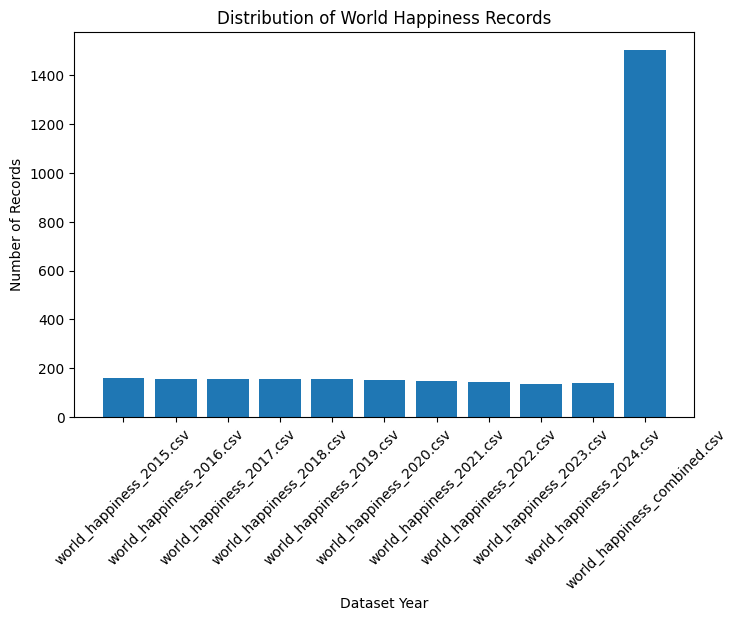

In [7]:
import matplotlib.pyplot as plt

year_count = df["Year_File"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(year_count.index, year_count.values)

plt.title("Distribution of World Happiness Records")
plt.xlabel("Dataset Year")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

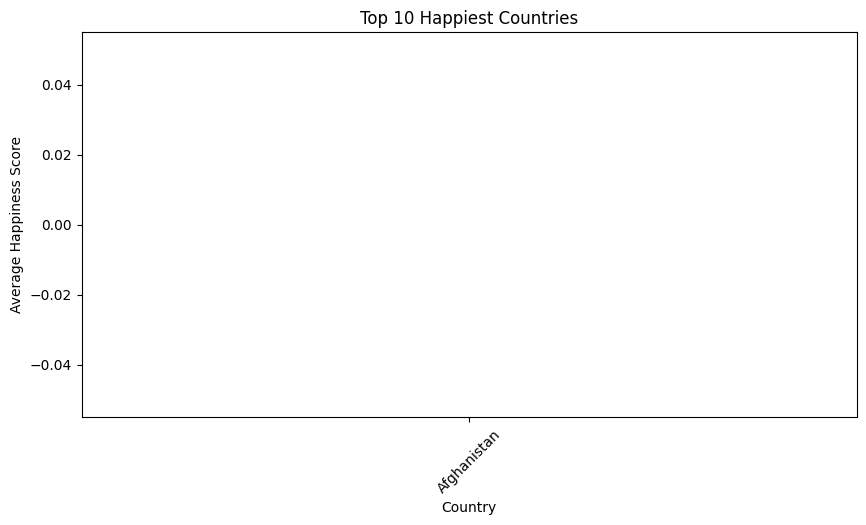

In [9]:
import matplotlib.pyplot as plt

# Data cleaning: Convert potential score columns to numeric
# Handle 'Happiness score' which might have comma decimals
if "Happiness score" in df.columns:
    df["Happiness score"] = df["Happiness score"].astype(str).str.replace(',', '.', regex=False)
    df["Happiness score"] = pd.to_numeric(df["Happiness score"], errors='coerce')

# Handle 'Ladder score' which might contain None or other non-numeric strings
if "Ladder score" in df.columns:
    df["Ladder score"] = pd.to_numeric(df["Ladder score"], errors='coerce')

# Detect happiness score column
if "Life Ladder" in df.columns:
    score = "Life Ladder"
elif "Ladder score" in df.columns:
    score = "Ladder score"
else:
    score = "Happiness score"

# Detect country column
if "Country name" in df.columns:
    country = "Country name"
else:
    country = "Country"

top10 = (
    df.groupby(country)[score]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(top10.index, top10.values)

plt.title("Top 10 Happiest Countries")
plt.xlabel("Country")
plt.ylabel("Average Happiness Score")

plt.xticks(rotation=45)

plt.show()